# Phần A: Đọc dữ liệu

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
spark = SparkSession.builder.appName("WebLogAnalysis_Large").getOrCreate()


In [2]:

df_logs = spark.read.csv("../data/web_logs.csv", header=True, inferSchema=True)

print("Schema của Log Web:")
df_logs.printSchema()
print(f"Tổng số bản ghi: {df_logs.count()}")

Schema của Log Web:
root
 |-- user_id: string (nullable = true)
 |-- page: string (nullable = true)
 |-- action: string (nullable = true)
 |-- device: string (nullable = true)
 |-- country: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)

Tổng số bản ghi: 1000000


# Phần B: Phân tích cơ bản

In [6]:

# 1. Đếm lượt truy cập theo page
print("\nLượt truy cập theo từng trang:")
df_logs.groupBy("page").count().orderBy(F.desc("count")).show()

# 2. Tìm 5 trang được truy cập nhiều nhất
print("Top 5 trang hot nhất:")
df_logs.groupBy("page").count().orderBy(F.desc("count")).limit(5).show()

# 3. Theo thiết bị và quốc gia
print("Phân phối theo thiết bị:")
df_logs.groupBy("device").count().show()

print("Phân phối theo quốc gia (Top 5):")
df_logs.groupBy("country").count().orderBy(F.desc("count")).limit(5).show()


Lượt truy cập theo từng trang:
+--------------+------+
|          page| count|
+--------------+------+
|          home|399611|
|  product_list|249863|
|product_detail|200127|
|          cart| 80412|
|      checkout| 49941|
|       payment| 20046|
+--------------+------+

Top 5 trang hot nhất:
+--------------+------+
|          page| count|
+--------------+------+
|          home|399611|
|  product_list|249863|
|product_detail|200127|
|          cart| 80412|
|      checkout| 49941|
+--------------+------+

Phân phối theo thiết bị:
+-------+------+
| device| count|
+-------+------+
|desktop|250413|
| mobile|699482|
| tablet| 50105|
+-------+------+

Phân phối theo quốc gia (Top 5):
+--------+------+
| country| count|
+--------+------+
| Vietnam|599934|
|     USA|150345|
|Thailand| 99843|
|   Korea| 50221|
|   Japan| 49893|
+--------+------+



# Phần C: Phân tích người dùng

In [7]:
# 1. Tính số lượng người dùng duy nhất (Unique Users)
# Sử dụng countDistinct để đếm chính xác từng User ID không trùng lặp
unique_users_count = df_logs.select(F.countDistinct("user_id")).collect()[0][0]
print(f"\nSố lượng người dùng duy nhất (MAU/DAU): {unique_users_count}")

# 2. Tìm 10 người dùng có số lượt truy cập nhiều nhất
print("Top 10 'Fan cứng' của Website:")
df_logs.groupBy("user_id").count().orderBy(F.desc("count")).show(10)


Số lượng người dùng duy nhất (MAU/DAU): 32478
Top 10 'Fan cứng' của Website:
+-------+-----+
|user_id|count|
+-------+-----+
| U19012|  155|
| U43743|  152|
| U17834|  150|
| U31291|  150|
| U40867|  147|
| U28634|  147|
| U01687|  145|
| U45876|  145|
| U32107|  145|
| U22614|  142|
+-------+-----+
only showing top 10 rows



# Phần D: Phân tích nâng cao

In [8]:

# 1. Tạo cột date từ timestamp
df_logs = df_logs.withColumn("date", F.to_date(F.col("timestamp")))

# 2. Tính số lượt truy cập theo ngày
print("Xu hướng truy cập theo ngày (10 ngày đầu):")
df_logs.groupBy("date").count().orderBy("date").show(10)

Xu hướng truy cập theo ngày (10 ngày đầu):
+----------+-----+
|      date|count|
+----------+-----+
|2026-01-01|11320|
|2026-01-02|11286|
|2026-01-03|11072|
|2026-01-04|11114|
|2026-01-05|11189|
|2026-01-06|11114|
|2026-01-07|10939|
|2026-01-08|10814|
|2026-01-09|10989|
|2026-01-10|11182|
+----------+-----+
only showing top 10 rows



In [9]:
# "Mỗi quốc gia, trang nào được xem nhiều nhất?"
df_logs.groupBy("country", "page").count().orderBy("country", F.desc("count")).show()

+---------+--------------+-----+
|  country|          page|count|
+---------+--------------+-----+
|    Japan|          home|20042|
|    Japan|  product_list|12470|
|    Japan|product_detail| 9970|
|    Japan|          cart| 4010|
|    Japan|      checkout| 2416|
|    Japan|       payment|  985|
|    Korea|          home|20107|
|    Korea|  product_list|12447|
|    Korea|product_detail|10045|
|    Korea|          cart| 4106|
|    Korea|      checkout| 2537|
|    Korea|       payment|  979|
|Singapore|          home|19655|
|Singapore|  product_list|12546|
|Singapore|product_detail|10096|
|Singapore|          cart| 3927|
|Singapore|      checkout| 2479|
|Singapore|       payment| 1061|
| Thailand|          home|39990|
| Thailand|  product_list|24769|
+---------+--------------+-----+
only showing top 20 rows



/tmp/ipykernel_3519/2948608771.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], data=page_pd, x='page', y='count', palette='Blues_r')
/tmp/ipykernel_3519/2948608771.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0], data=country_pd, x='country', y='count', palette='Set2')
/tmp/ipykernel_3519/2948608771.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 1], data=top_users_pd, x='user_id', y='count', palette='rocket')


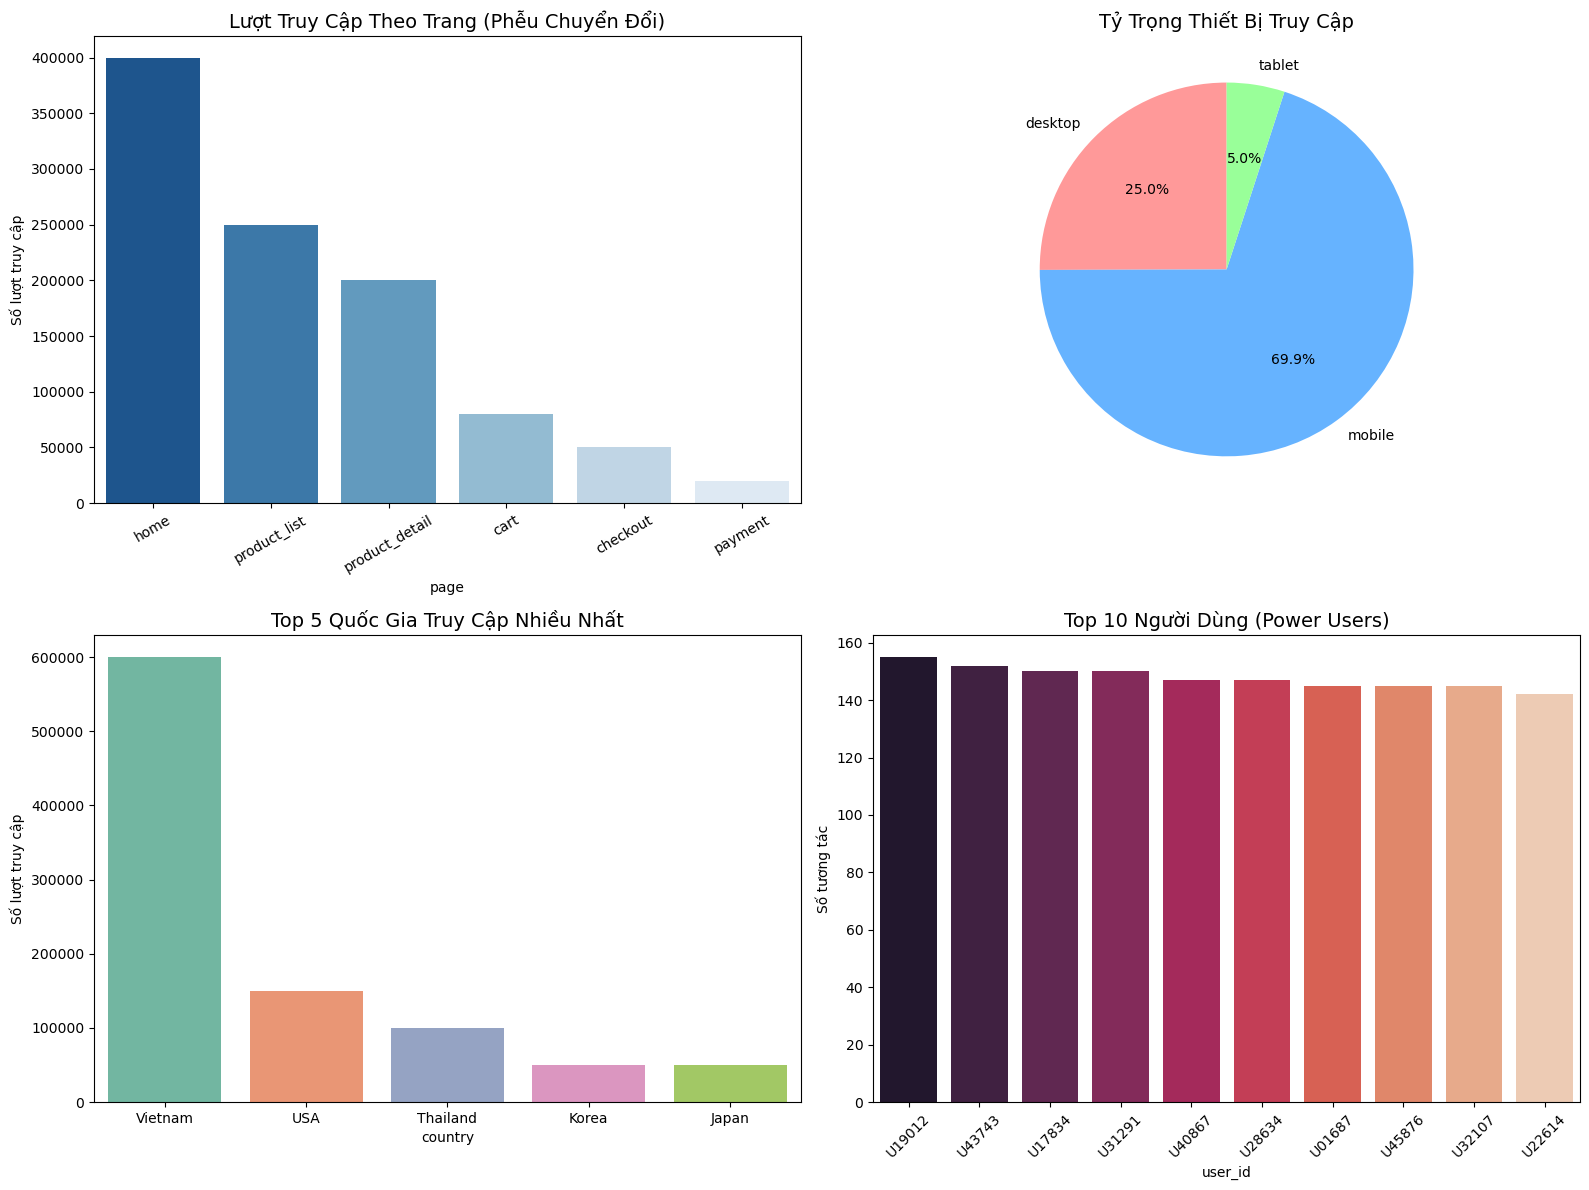

In [10]:


# --- 1. DÙNG SPARK ĐỂ TỔNG HỢP DỮ LIỆU (AGGREGATION) ---
# Lượt truy cập theo trang (Phễu)
page_pd = df_logs.groupBy("page").count().orderBy(F.desc("count")).toPandas()

# Lượt truy cập theo thiết bị
device_pd = df_logs.groupBy("device").count().toPandas()

# Top 5 Quốc gia
country_pd = df_logs.groupBy("country").count().orderBy(F.desc("count")).limit(5).toPandas()

# Top 10 Người dùng "cày view" nhiều nhất
top_users_pd = df_logs.groupBy("user_id").count().orderBy(F.desc("count")).limit(10).toPandas()


# --- 2. VẼ BIỂU ĐỒ TRỰC QUAN ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Biểu đồ 1: Phễu chuyển đổi trang (Bar Chart)
sns.barplot(ax=axes[0, 0], data=page_pd, x='page', y='count', palette='Blues_r')
axes[0, 0].set_title('Lượt Truy Cập Theo Trang (Phễu Chuyển Đổi)', fontsize=14)
axes[0, 0].set_ylabel('Số lượt truy cập')
axes[0, 0].tick_params(axis='x', rotation=30)

# Biểu đồ 2: Tỷ trọng thiết bị (Pie Chart)
axes[0, 1].pie(device_pd['count'], labels=device_pd['device'], autopct='%1.1f%%', 
               colors=['#ff9999','#66b3ff','#99ff99'], startangle=90)
axes[0, 1].set_title('Tỷ Trọng Thiết Bị Truy Cập', fontsize=14)

# Biểu đồ 3: Top 5 Quốc gia (Bar Chart)
sns.barplot(ax=axes[1, 0], data=country_pd, x='country', y='count', palette='Set2')
axes[1, 0].set_title('Top 5 Quốc Gia Truy Cập Nhiều Nhất', fontsize=14)
axes[1, 0].set_ylabel('Số lượt truy cập')

# Biểu đồ 4: Top 10 Người dùng tích cực nhất (Bar Chart)
sns.barplot(ax=axes[1, 1], data=top_users_pd, x='user_id', y='count', palette='rocket')
axes[1, 1].set_title('Top 10 Người Dùng (Power Users)', fontsize=14)
axes[1, 1].set_ylabel('Số tương tác')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()